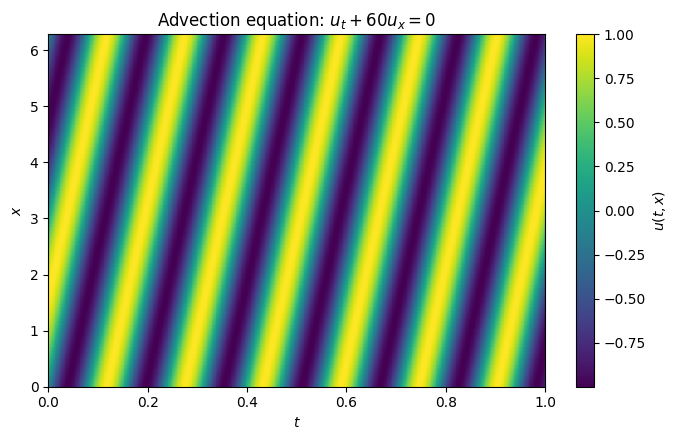

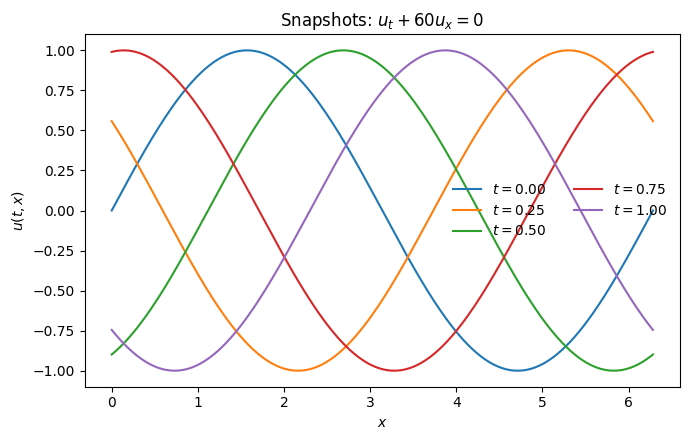

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem:
# u_t + c u_x = 0,  (t, x) in [0, T] x [0, L]
# u(0, x) = sin(x)
# periodic boundary: u(t, 0) = u(t, L)
#
# Exact solution:
# u(t, x) = sin((x - c t) mod L)

T = 1.0
L = 2 * np.pi
c = 40

n_t = 600
n_x = 256

# Grid
t_star = np.linspace(0.0, T, n_t)
x_star = np.linspace(0.0, L, n_x)

TT, XX = np.meshgrid(t_star, x_star, indexing="ij")

# Exact solution
X_shift = (XX - c * TT) % L
u_ref = np.sin(X_shift)

# Save data
np.savez(
    "advection_c40_data.npz",
    u_ref=u_ref,
    t_star=t_star,
    x_star=x_star,
    c=c,
    T=T,
    L=L,
)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    u_ref.T,
    origin="lower",
    aspect="auto",
    extent=[t_star[0], t_star[-1], x_star[0], x_star[-1]],
    interpolation="nearest",
)
cb = fig.colorbar(im, ax=ax)
cb.set_label(r"$u(t,x)$")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_title(r"Advection equation: $u_t + 60u_x = 0$")

fig.tight_layout()
plt.savefig("advection_c40_heatmap.png", dpi=300)
plt.show()

# Optional: solution snapshots
snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, ax = plt.subplots(figsize=(7, 4.5))
for ts in snapshot_times:
    idx = np.argmin(np.abs(t_star - ts))
    ax.plot(x_star, u_ref[idx], label=rf"$t={t_star[idx]:.2f}$")

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(t,x)$")
ax.set_title(r"Snapshots: $u_t + 60u_x = 0$")
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
plt.savefig("advection_c40_snapshots.png", dpi=300)
plt.show()

In [1]:
# ============================================================
# SQP-PINN for 1D Linear Transport / Advection
#
# PDE:
#   u_t + c u_x = 0,  (x,t) in [0,L] x [0,T]
#
# IC:
#   u(x,0) = sin(x)
#
# Periodic value BC only:
#   u(0,t) - u(L,t) = 0
#
# NO derivative BC.
# Fixed KKT damping: mu_damp = 1e-4.
# Fixed base collocation points + fresh jitter noise every iteration.
# Input normalization inside NN: physical (x,t) -> [-1,1]^2.
# Residual scaled by sqrt(1+c^2) for high-speed transport.
# ============================================================

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import math
from functools import partial
import numpy as np

import jax
jax.config.update("jax_default_matmul_precision", "tensorfloat32")
import jax.numpy as jnp
from jax import random, grad, vmap

USE_X64 = True
jax.config.update("jax_enable_x64", USE_X64)
DTYPE = jnp.float64 if USE_X64 else jnp.float32
EPS = DTYPE(1e-12)

# ============================================================
# Problem
# ============================================================
T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0          # if unstable, test 10.0 -> 20.0 -> 60.0

N_T_REF = 600
N_X_REF = 256

x_min = DTYPE(0.0)
x_max = DTYPE(L_DOMAIN)
t_min = DTYPE(0.0)
t_max = DTYPE(T_FINAL)

# ============================================================
# Sample counts
# ============================================================
NX_PDE_OBJ = 80
NT_PDE_OBJ = 80
K_PDE_OBJ = NX_PDE_OBJ * NT_PDE_OBJ

NX_PDE_CON = 30
NT_PDE_CON = 30
K_PDE = NX_PDE_CON * NT_PDE_CON
N_PDE_PER_CELL = 1

K_BC = 100
N_BC_PER_BIN = 1

K_IC = 300
N_IC_PER_BIN = 1

M_CON = K_PDE + K_BC + K_IC

# ============================================================
# Network
# ============================================================
def init_mlp_params(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = random.normal(k, (m, n), dtype=DTYPE) * jnp.sqrt(DTYPE(2.0) / DTYPE(m))
        b = jnp.zeros((n,), dtype=DTYPE)
        params.append({"W": W, "b": b})
    return params


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]
    x_n = DTYPE(2.0) * (x - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (t - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)
    return jnp.concatenate([x_n, t_n], axis=1)


def mlp_apply(params, X):
    h = normalize_xt(X)
    for i, layer in enumerate(params):
        W, b = layer["W"], layer["b"]
        h = h @ W + b
        if i < len(params) - 1:
            h = jnp.tanh(h)
    return h


def flatten_params(params):
    flat_parts = []
    shapes = []
    for layer in params:
        W, b = layer["W"], layer["b"]
        flat_parts.append(W.reshape(-1))
        flat_parts.append(b.reshape(-1))
        shapes.append((W.shape, b.shape))
    return jnp.concatenate(flat_parts).astype(DTYPE), tuple(shapes)


def unflatten_params(theta, shapes):
    params = []
    idx = 0
    for W_shape, b_shape in shapes:
        W_size = math.prod(W_shape)
        b_size = math.prod(b_shape)
        W = theta[idx:idx + W_size].reshape(W_shape)
        idx += W_size
        b = theta[idx:idx + b_size].reshape(b_shape)
        idx += b_size
        params.append({"W": W, "b": b})
    if idx != theta.size:
        raise ValueError(f"Used {idx}, theta size {theta.size}")
    return params

# ============================================================
# Data
# ============================================================
def generate_transport_dataset(T=T_FINAL, L=L_DOMAIN, c=C_ADV, n_t=N_T_REF, n_x=N_X_REF):
    t = np.linspace(0.0, T, n_t)
    x = np.linspace(0.0, L, n_x)
    TT, XX = np.meshgrid(t, x, indexing="ij")
    u = np.sin((XX - c * TT) % L)
    return t, x, u, float(c)

# ============================================================
# Sampling
# ============================================================
def segment_sum(values, segment_ids, num_segments):
    out = jnp.zeros((num_segments,), dtype=values.dtype)
    return out.at[segment_ids].add(values)


def sample_pde_obj_base_stratified(key):
    dx = (x_max - x_min) / DTYPE(NX_PDE_OBJ)
    dt = (t_max - t_min) / DTYPE(NT_PDE_OBJ)
    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_OBJ), jnp.arange(NX_PDE_OBJ), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)
    xb = x_min + DTYPE(ix) * dx
    tb = t_min + DTYPE(it) * dt
    u = random.uniform(key, (K_PDE_OBJ, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    return jnp.stack([xb + u[:, 0] * dx, tb + u[:, 1] * dt], axis=1)


def sample_pde_con_stratified(key):
    dx = (x_max - x_min) / DTYPE(NX_PDE_CON)
    dt = (t_max - t_min) / DTYPE(NT_PDE_CON)
    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_CON), jnp.arange(NX_PDE_CON), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)
    ids_cell = (it * NX_PDE_CON + ix).astype(jnp.int32)
    xb = x_min + DTYPE(ix) * dx
    tb = t_min + DTYPE(it) * dt
    u = random.uniform(key, (K_PDE, N_PDE_PER_CELL, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = xb[:, None] + u[:, :, 0] * dx
    ts = tb[:, None] + u[:, :, 1] * dt
    X = jnp.stack([xs, ts], axis=-1).reshape(-1, 2)
    ids = jnp.repeat(ids_cell, N_PDE_PER_CELL)
    return X, ids


def sample_bc_stratified(key):
    dt = (t_max - t_min) / DTYPE(K_BC)
    j = jnp.arange(K_BC, dtype=jnp.int32)
    tb = t_min + DTYPE(j) * dt
    u = random.uniform(key, (K_BC, N_BC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    ts = (tb[:, None] + u * dt).reshape(-1, 1)
    ids = jnp.repeat(j, N_BC_PER_BIN)
    XL = jnp.concatenate([x_min * jnp.ones_like(ts), ts], axis=1)
    XR = jnp.concatenate([x_max * jnp.ones_like(ts), ts], axis=1)
    return XL, XR, ids


def sample_ic_stratified(key):
    dx = (x_max - x_min) / DTYPE(K_IC)
    j = jnp.arange(K_IC, dtype=jnp.int32)
    xb = x_min + DTYPE(j) * dx
    u = random.uniform(key, (K_IC, N_IC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = (xb[:, None] + u * dx).reshape(-1, 1)
    ids = jnp.repeat(j, N_IC_PER_BIN)
    Xic = jnp.concatenate([xs, t_min * jnp.ones_like(xs)], axis=1)
    u0 = jnp.sin(xs[:, 0])
    return Xic, u0, ids


def jitter_points(key, X, sx, st, clip_k=2.0, keep_x=None, keep_t0=False):
    if X.shape[0] == 0 or (sx <= 0.0 and st <= 0.0):
        return X
    key, kx, kt = random.split(key, 3)
    dx = DTYPE(sx) * random.normal(kx, (X.shape[0],), dtype=DTYPE)
    dt = DTYPE(st) * random.normal(kt, (X.shape[0],), dtype=DTYPE)
    ck = DTYPE(clip_k)
    dx = jnp.clip(dx, -ck * DTYPE(sx), ck * DTYPE(sx))
    dt = jnp.clip(dt, -ck * DTYPE(st), ck * DTYPE(st))
    x = jnp.clip(X[:, 0] + dx, x_min, x_max)
    t = jnp.clip(X[:, 1] + dt, t_min, t_max)
    if keep_x is not None:
        x = DTYPE(keep_x) * jnp.ones_like(x)
    if keep_t0:
        t = t_min * jnp.ones_like(t)
    return jnp.stack([x, t], axis=1)

# ============================================================
# PDE and constraints
# ============================================================
def pde_residual(params, X, c):
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]
    du = vmap(grad(u_fun))(X)
    u_x = du[:, 0]
    u_t = du[:, 1]
    return (u_t + DTYPE(c) * u_x) / jnp.sqrt(DTYPE(1.0) + DTYPE(c) ** 2)


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_pde_obj(theta, shapes, X_obj, c, w_pde):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        r = pde_residual(params, X_obj, c)
        return DTYPE(w_pde) * jnp.mean(r ** 2)
    val, g = jax.value_and_grad(obj_theta)(theta)
    return val, g


@partial(jax.jit, static_argnames=("shapes",))
def constraint_vector(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c):
    params = unflatten_params(theta, shapes)
    r = pde_residual(params, X_f, c)
    c_pde = segment_sum(r, ids_f, K_PDE) / DTYPE(N_PDE_PER_CELL)
    uL = mlp_apply(params, X_bc_L)[:, 0]
    uR = mlp_apply(params, X_bc_R)[:, 0]
    c_bc = segment_sum(uL - uR, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)
    u_ic = mlp_apply(params, X_ic)[:, 0]
    c_ic = segment_sum(u_ic - u0_ic, ids_ic, K_IC) / DTYPE(N_IC_PER_BIN)
    return jnp.concatenate([c_pde, c_bc, c_ic], axis=0)


@partial(jax.jit, static_argnames=("shapes",))
def C_and_J(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c):
    def c_fun(th):
        return constraint_vector(th, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c)
    def c_fun_aux(th):
        cc = c_fun(th)
        return cc, cc
    J, cc = jax.jacrev(c_fun_aux, has_aux=True)(theta)
    return cc, J


@partial(jax.jit, static_argnames=("shapes",))
def C_only(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c):
    return constraint_vector(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, c)

# ============================================================
# KKT and step helpers
# ============================================================
@jax.jit
def kkt_solve_once(H, Jac, Grad, Cons, mu_damp):
    n = H.shape[0]
    m = Cons.shape[0]
    I_m = jnp.eye(m, dtype=H.dtype)
    top = jnp.concatenate([H, Jac.T], axis=1)
    bottom = jnp.concatenate([Jac, -mu_damp * I_m], axis=1)
    KKT = jnp.concatenate([top, bottom], axis=0)
    rhs = -jnp.concatenate([Grad, Cons])
    sol = jnp.linalg.solve(KKT, rhs)
    return sol[:n], sol[n:]


def cal_tau_mu(H, d, sigma, tau_pre, eps_tau, g, c, mu_eff, y):
    denom = float(g @ d + 0.5 * (d @ (H @ d)))
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1
    if (denom <= 1e-12) or (delta_c <= 0.0):
        tau_trial = float("inf")
    else:
        tau_trial = (1.0 - sigma) * delta_c / denom
    if tau_pre <= tau_trial:
        return tau_pre
    return min(tau_trial, (1.0 - eps_tau) * tau_pre)


def cal_ksi_mu(d, tau, ksi_old, eps_ksi, g, c, mu_eff, y):
    d2 = float(jnp.linalg.norm(d) ** 2)
    if d2 <= 1e-18 or tau <= 1e-18:
        return ksi_old
    gd = float(g @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1
    Dl = -tau * gd + delta_c
    ksi_trial = max(0.0, Dl / (tau * d2))
    if ksi_old <= ksi_trial:
        return ksi_old
    return min(ksi_trial, (1.0 - eps_ksi) * ksi_old)


def phi_mu(alpha, eta, beta, tau, g, d, c, mu_eff, y, L_lip, Gamma_lip):
    gd = float(g @ d)
    d2 = float(d @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1
    Dl = -tau * gd + delta_c
    return ((eta - 1.0) * alpha * beta * Dl
            + (abs(1.0 - alpha) - 1.0 + alpha) * c1
            + 0.5 * (tau * L_lip + Gamma_lip) * (alpha ** 2) * d2)


def cal_alpha_mu(d, eta, beta, ksi, tau, L_lip, Gamma_lip, theta_val, g, c, mu_eff, y):
    denom = tau * L_lip + Gamma_lip
    if denom <= 1e-12:
        return 0.0
    alpha_min = 2.0 * (1.0 - eta) * beta * ksi * tau / denom
    a = max(alpha_min, 0.0)
    for _ in range(30):
        if not (phi_mu(1.1 * a, eta, beta, tau, g, d, c, mu_eff, y, L_lip, Gamma_lip) < 0.0
                and (1.1 * a < alpha_min + theta_val * beta)):
            break
        a *= 1.1
    return float(a)

# ============================================================
# Eval
# ============================================================
def make_grid_points(x_np, t_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    return np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1), TT.shape


@partial(jax.jit, static_argnames=("shapes",))
def predict_u(theta, shapes, X):
    params = unflatten_params(theta, shapes)
    return mlp_apply(params, X)[:, 0]


def eval_full_grid(theta, shapes, x_np, t_np, usol_np):
    X_grid_np, grid_shape = make_grid_points(x_np, t_np)
    X_grid = jnp.asarray(X_grid_np, dtype=DTYPE)
    u_pred = np.asarray(predict_u(theta, shapes, X_grid)).reshape(grid_shape)
    mse = float(np.mean((u_pred - usol_np) ** 2))
    rel = float(np.linalg.norm(u_pred - usol_np) / (np.linalg.norm(usol_np) + 1e-12))
    return mse, rel, u_pred


def rms(x):
    return float(jnp.sqrt(jnp.mean(x ** 2) + EPS))


def maxabs(x):
    return float(jnp.max(jnp.abs(x)))

# ============================================================
# Training
# ============================================================
def train_sqp_transport(
    seed=0,
    hidden_dim=30,
    num_hidden=3,
    max_iters=3000,
    print_every=10,
    eval_every=100,
    w_pde_obj=1.0,
    beta_shift=400.0,
    beta_power=0.6,
    alpha_cap=1e1,
    L_lip=60.0,
    Gamma_lip=60.0,
    mu_damp=1e-4,
    jitter_every_iter=True,
    jitter_sigma_x=1e-5,
    jitter_sigma_t=1e-5,
    jitter_clip_k=2.0,
):
    t_np, x_np, usol_np, c = generate_transport_dataset()
    print("generated transport data:", "t", t_np.shape, "x", x_np.shape, "usol", usol_np.shape, "c", c)
    print(f"Domain: x=[{x_np.min()}, {x_np.max()}], t=[{t_np.min()}, {t_np.max()}]")
    print("Input normalization: ON")
    print("Derivative BC: OFF")
    print("Fixed damping mu_damp:", mu_damp)
    print("M_CON:", M_CON)

    layer_sizes = [2] + [hidden_dim] * num_hidden + [1]
    key = random.PRNGKey(seed)
    key, k0 = random.split(key)
    params0 = init_mlp_params(k0, layer_sizes)
    theta, shapes = flatten_params(params0)
    n = theta.shape[0]
    H = jnp.eye(n, dtype=DTYPE)

    key, k_obj, k_con, k_bc, k_ic = random.split(key, 5)
    X_obj_base = sample_pde_obj_base_stratified(k_obj)
    X_f_base, ids_f = sample_pde_con_stratified(k_con)
    XL_base, XR_base, ids_bc = sample_bc_stratified(k_bc)
    Xic_base, u0ic_base, ids_ic = sample_ic_stratified(k_ic)

    eta, sigma = 0.25, 0.1
    eps_tau, eps_ksi = 1e-2, 1e-2
    theta_val = 10.0
    tau_k, ksi_k = 1.0, 1.0

    best_rel = float("inf")
    best_theta = theta
    t0_wall = time.time()

    for it in range(1, max_iters + 1):
        k_beta = (it // 10) * 10
        beta_k = float(min(1.0, (beta_shift / (beta_shift + k_beta)) ** beta_power))

        if jitter_every_iter:
            key, kj_obj, kj_f, kj_bc, kj_ic = random.split(key, 5)
            X_obj = jitter_points(kj_obj, X_obj_base, jitter_sigma_x, jitter_sigma_t, jitter_clip_k)
            X_f = jitter_points(kj_f, X_f_base, jitter_sigma_x, jitter_sigma_t, jitter_clip_k)
            XL = jitter_points(kj_bc, XL_base, 0.0, jitter_sigma_t, jitter_clip_k, keep_x=float(x_min))
            XR = jitter_points(kj_bc, XR_base, 0.0, jitter_sigma_t, jitter_clip_k, keep_x=float(x_max))
            Xic = jitter_points(kj_ic, Xic_base, jitter_sigma_x, 0.0, jitter_clip_k, keep_t0=True)
            u0ic = jnp.sin(Xic[:, 0])
        else:
            X_obj = X_obj_base
            X_f = X_f_base
            XL = XL_base
            XR = XR_base
            Xic = Xic_base
            u0ic = u0ic_base

        obj_val, g = F_and_g_pde_obj(theta, shapes, X_obj, DTYPE(c), DTYPE(w_pde_obj))
        cons, J = C_and_J(theta, shapes, X_f, ids_f, XL, XR, ids_bc, Xic, u0ic, ids_ic, DTYPE(c))
        d, y = kkt_solve_once(H, J, g, cons, DTYPE(mu_damp))
        dn = float(jnp.linalg.norm(d, jnp.inf))

        if dn > 1e-12:
            tau_k = cal_tau_mu(H, d, sigma, tau_k, eps_tau, g, cons, DTYPE(mu_damp), y)
            ksi_k = cal_ksi_mu(d, tau_k, ksi_k, eps_ksi, g, cons, DTYPE(mu_damp), y)
            alpha = cal_alpha_mu(d, eta, beta_k, ksi_k, tau_k, L_lip, Gamma_lip, theta_val, g, cons, DTYPE(mu_damp), y)
        else:
            alpha = 0.0

        alpha = float(min(alpha, alpha_cap))
        if not np.isfinite(alpha) or not np.isfinite(dn):
            print("[STOP] nonfinite alpha/direction")
            break
        if dn > 1e4:
            print(f"[STOP] huge direction dn={dn:.3e}; reduce alpha_cap or increase mu_damp")
            break

        theta = theta + DTYPE(alpha) * d

        if it % print_every == 0:
            c_now = C_only(theta, shapes, X_f, ids_f, XL, XR, ids_bc, Xic, u0ic, ids_ic, DTYPE(c))
            c_pde = c_now[:K_PDE]
            c_bc = c_now[K_PDE:K_PDE + K_BC]
            c_ic = c_now[K_PDE + K_BC:]
            feas = float(jnp.mean(c_now ** 2))
            station = float(jnp.linalg.norm(g + J.T @ y, jnp.inf))
            print(
                f"[it={it}] obj={float(obj_val):.3e} feas={feas:.3e} "
                f"alpha={alpha:.2e} beta={beta_k:.2e} station={station:.2e} dn={dn:.2e} "
                f"| PDE=({rms(c_pde):.2e},{maxabs(c_pde):.2e}) "
                f"BCv=({rms(c_bc):.2e},{maxabs(c_bc):.2e}) "
                f"IC=({rms(c_ic):.2e},{maxabs(c_ic):.2e})"
            )

        if eval_every and it % eval_every == 0:
            mse, rel, _ = eval_full_grid(theta, shapes, x_np, t_np, usol_np)
            print(f"    [eval] mse={mse:.3e} relL2={rel:.3e}")
            if rel < best_rel:
                best_rel = rel
                best_theta = theta
                np.save("theta_sqp_transport_best.npy", np.asarray(best_theta))
                print(f"    >>> new best relL2={best_rel:.3e}; saved")

    print(f"[done] elapsed={time.time() - t0_wall:.2f}s")
    mse, rel, _ = eval_full_grid(theta, shapes, x_np, t_np, usol_np)
    print(f"[FINAL] MSE={mse:.3e} relL2={rel:.3e}")
    mse_b, rel_b, _ = eval_full_grid(best_theta, shapes, x_np, t_np, usol_np)
    print(f"[BEST]  MSE={mse_b:.3e} relL2={rel_b:.3e}")
    np.save("theta_sqp_transport_final.npy", np.asarray(theta))
    return theta, shapes


def main():
    theta, shapes = train_sqp_transport(
        seed=0,
        hidden_dim=30,
        num_hidden=3,
        max_iters=10000,
        print_every=10,
        eval_every=100,
        w_pde_obj=10.0,
        alpha_cap=1e2,
        L_lip=60.0,
        Gamma_lip=60.0,
        mu_damp=1e-4,
        jitter_every_iter=True,
        jitter_sigma_x=1e-5,
        jitter_sigma_t=2.5e-7,
        jitter_clip_k=2.0,
    )
    return theta, shapes


if __name__ == "__main__":
    main()


generated transport data: t (600,) x (256,) usol (600, 256) c 40.0
Domain: x=[0.0, 6.283185307179586], t=[0.0, 1.0]
Input normalization: ON
Derivative BC: OFF
Fixed damping mu_damp: 0.0001
M_CON: 1300
[it=10] obj=1.016e-01 feas=1.563e-01 alpha=6.16e-04 beta=9.85e-01 station=1.52e+01 dn=1.52e+01 | PDE=(1.01e-01,2.58e-01) BCv=(2.89e-01,4.54e-01) IC=(7.87e-01,1.16e+00)
[it=20] obj=9.894e-02 feas=1.545e-01 alpha=6.07e-04 beta=9.71e-01 station=1.86e+01 dn=1.86e+01 | PDE=(1.00e-01,2.54e-01) BCv=(2.85e-01,4.48e-01) IC=(7.82e-01,1.16e+00)
[it=30] obj=9.733e-02 feas=1.527e-01 alpha=7.25e-04 beta=9.58e-01 station=1.67e+01 dn=1.67e+01 | PDE=(9.93e-02,2.53e-01) BCv=(2.82e-01,4.43e-01) IC=(7.78e-01,1.15e+00)
[it=40] obj=9.645e-02 feas=1.505e-01 alpha=7.86e-04 beta=9.44e-01 station=1.81e+01 dn=1.81e+01 | PDE=(9.89e-02,2.52e-01) BCv=(2.80e-01,4.41e-01) IC=(7.73e-01,1.15e+00)
[it=50] obj=9.533e-02 feas=1.479e-01 alpha=1.03e-03 beta=9.32e-01 station=1.95e+01 dn=1.95e+01 | PDE=(9.83e-02,2.51e-01) BCv=(2

Loaded theta: theta_sqp_transport_best.npy
theta size: 1981
Expected theta size: 1981
t shape: (600,)
x shape: (256,)
u_true shape: (600, 256)
[EVAL] full-grid MSE   = 6.047252e-06
[EVAL] full-grid relL2 = 3.477636e-03
Saved: transport_sqp_prediction_heatmap.png
Saved: transport_sqp_prediction_heatmap.pdf


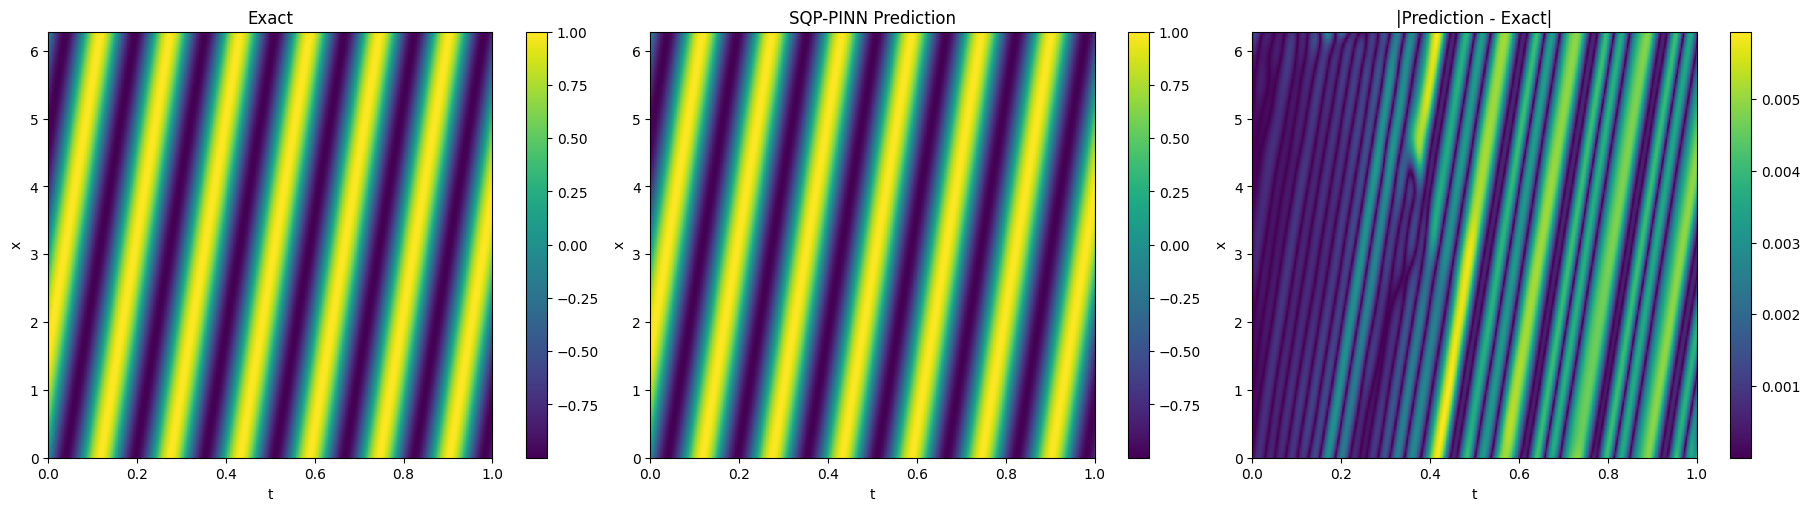

In [2]:
# ============================================================
# Standalone SQP-PINN heatmap for transport/advection
#
# Works even if predict_u / eval_full_grid / generate_transport_dataset
# are not currently defined in the notebook.
# ============================================================

import os
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# ============================================================
# Problem setup: match your run
# ============================================================

T_FINAL = 1.0
L_DOMAIN = 2.0 * np.pi
C_ADV = 40.0

N_T_REF = 600
N_X_REF = 256

DTYPE = jnp.float64
EPS = DTYPE(1e-12)

x_min = DTYPE(0.0)
x_max = DTYPE(L_DOMAIN)
t_min = DTYPE(0.0)
t_max = DTYPE(T_FINAL)

# ============================================================
# Find/load saved SQP theta
# ============================================================

theta_candidates = [
    "theta_sqp_transport_best.npy",
    "theta_sqp_transport_final.npy",
    "theta_transport_c60_stosqp_fixed_damp.npy",
    "theta_transport_c40_stosqp_fixed_damp.npy",
]

theta_path = None
for p in theta_candidates:
    if Path(p).exists():
        theta_path = p
        break

if theta_path is None:
    raise FileNotFoundError(
        "Could not find saved theta. Checked:\n"
        + "\n".join(theta_candidates)
        + "\n\nIf your file has a different name, set theta_path manually."
    )

theta_np = np.load(theta_path)
theta = jnp.asarray(theta_np, dtype=DTYPE)

print("Loaded theta:", theta_path)
print("theta size:", theta_np.size)

# ============================================================
# Architecture
# Your run used hidden_dim=30, num_hidden=3 unless you changed it.
# ============================================================

hidden_dim = 30
num_hidden = 3
layer_sizes = [2] + [hidden_dim] * num_hidden + [1]

def expected_param_count(layer_sizes):
    total = 0
    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += m * n + n
    return total

expected = expected_param_count(layer_sizes)
print("Expected theta size:", expected)

if theta_np.size != expected:
    raise ValueError(
        f"Theta size {theta_np.size} does not match architecture {layer_sizes} "
        f"with expected size {expected}. "
        "If you trained with a different hidden_dim/num_hidden, change them above."
    )

# ============================================================
# Network helpers
# ============================================================

def unflatten_params(theta, layer_sizes):
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape((m, n))
        idx += w_size

        b = theta[idx:idx + b_size].reshape((n,))
        idx += b_size

        params.append({"W": W, "b": b})

    if idx != theta.size:
        raise ValueError(f"Used {idx} params, but theta has {theta.size}")

    return params


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = DTYPE(2.0) * (x - x_min) / (x_max - x_min + EPS) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (t - t_min) / (t_max - t_min + EPS) - DTYPE(1.0)

    return jnp.concatenate([x_n, t_n], axis=1)


def mlp_apply(params, X):
    h = normalize_xt(X)

    for i, layer in enumerate(params):
        h = h @ layer["W"] + layer["b"]
        if i < len(params) - 1:
            h = jnp.tanh(h)

    return h


params = unflatten_params(theta, layer_sizes)

@jax.jit
def predict_batch(X):
    return mlp_apply(params, X)[:, 0]

# ============================================================
# Recreate exact transport data
# ============================================================

t_np = np.linspace(0.0, T_FINAL, N_T_REF)
x_np = np.linspace(0.0, L_DOMAIN, N_X_REF)

TT, XX = np.meshgrid(t_np, x_np, indexing="ij")

usol_np = np.sin((XX - C_ADV * TT) % L_DOMAIN)

print("t shape:", t_np.shape)
print("x shape:", x_np.shape)
print("u_true shape:", usol_np.shape)

# ============================================================
# Predict SQP-PINN on full grid
# ============================================================

X_grid = np.stack(
    [XX.reshape(-1), TT.reshape(-1)],
    axis=1,
)

chunk = 65536
pred_chunks = []

for s in range(0, X_grid.shape[0], chunk):
    X_chunk = jnp.asarray(X_grid[s:s + chunk], dtype=DTYPE)
    pred_chunks.append(np.asarray(predict_batch(X_chunk)))

u_pred = np.concatenate(pred_chunks, axis=0).reshape(usol_np.shape)

# ============================================================
# Metrics
# ============================================================

mse = np.mean((u_pred - usol_np) ** 2)
rel_l2 = np.linalg.norm(u_pred - usol_np) / (np.linalg.norm(usol_np) + 1e-12)

print(f"[EVAL] full-grid MSE   = {mse:.6e}")
print(f"[EVAL] full-grid relL2 = {rel_l2:.6e}")

# ============================================================
# Heatmaps
# ============================================================

err = np.abs(u_pred - usol_np)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

vmin = min(float(usol_np.min()), float(u_pred.min()))
vmax = max(float(usol_np.max()), float(u_pred.max()))

# Exact
im0 = axes[0].imshow(
    usol_np.T,
    origin="lower",
    aspect="auto",
    extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Exact")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x")
fig.colorbar(im0, ax=axes[0])

# SQP-PINN prediction
im1 = axes[1].imshow(
    u_pred.T,
    origin="lower",
    aspect="auto",
    extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("SQP-PINN Prediction")
axes[1].set_xlabel("t")
axes[1].set_ylabel("x")
fig.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].imshow(
    err.T,
    origin="lower",
    aspect="auto",
    extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
    interpolation="nearest",
)
axes[2].set_title("|Prediction - Exact|")
axes[2].set_xlabel("t")
axes[2].set_ylabel("x")
fig.colorbar(im2, ax=axes[2])

plt.savefig("transport_sqp_prediction_heatmap.png", dpi=300)
plt.savefig("transport_sqp_prediction_heatmap.pdf")

print("Saved: transport_sqp_prediction_heatmap.png")
print("Saved: transport_sqp_prediction_heatmap.pdf")

plt.show()